### Assignment: Linear Regression with Regularization <font color='red'>**[50 points]**</font>

## Objective
The goal of this assignment is to understand the implementation of linear regression and its extension with L1 (Lasso) and L2 (Ridge) regularization. You will apply regression techniques to real-world datasets, analyze the impact of regularization, and explore the effect of dataset size on model performance.

## 1. Choice of Dataset <font color='red'>**[6 points]**</font>
- You can choose any appropriate dataset from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/datasets) for this assignment.
- The dataset should be suitable for **regression tasks** (e.g., predicting house prices, forecasting sales, or any continuous value prediction).
- You need to append all the datasets used in the experiments in separate **CSV files** and submit it along with your **IPYNB code**. <font color='red'>**Zero marking otherwise!**</font>

## Instructions
### 2. Implement Linear Regression <font color='red'>**[10 points]**</font>
- Implement **Ordinary Least Squares (OLS) Linear Regression** using gradient descent.
- Train the model on a **dataset of your choice from the UCI repository**.
- Select **a random subset of 5000 entries** from the UCI-dataset of your choice to create a smaller dataset.
- Split the dataset into **train (60%) and test sets (40%)**
- Report **Squared Loss** and **Absolute Loss** as the evaluation metric.

### 3. Implement L1 and L2 Regularization <font color='red'>**[10 points]**</font>
- Modify the linear regression implementation to include **L1 (Lasso) and L2 (Ridge) regularization**.
- Split the dataset into **train (60%), validation (CV), and test sets (40%)** for proper parameter tuning. Use **k-fold cross-validation**.
- Report **Squared Loss** or **Absolute Loss** as the evaluation metric with and without regularization. Compare the results.
- Analyze how L1 and L2 affect feature selection and weight shrinkage.

### 4. Dataset Scaling and Observations
(A) **Vary training set size**: <font color='red'>**[10 points]**</font>
- Set training set sizes to **20%, 40%, 60%, and 80%** while using the remaining data as the test set. Use **k-fold cross-validation**.
- Use  and plot the **test error with increasing training set size**, as instructed in **#3**.
- **Report observations and inferences** on model performance.

(B) **Increase dataset size**: <font color='red'>**[10 points]**</font>
- Expand the dataset to **10K and 20K samples** and perform the same task as in (4A).
- **Report observations and inferences** on how dataset size affects generalization.

### 5. Additional Questions <font color='red'>**[2+2 points]**</font>
- **How do you select the appropriate value of k in k-fold cross-validation?** Discuss the trade-off between bias and variance when choosing k.
- **Handling Missing Data**: How did you handle missing or NaN entries in the dataset? Explain the method used and why it was chosen.

## Hints
- Use `numpy` for efficient matrix operations.
- Use `matplotlib` to visualize loss trends.
- Utilize `scikit-learn` functions for dataset preprocessing.
- Ensure numerical stability by implementing proper initialization and gradient clipping where necessary.


### 1. Choice of Dataset
Fernandes, K., Vinagre, P., Cortez, P., & Sernadela, P. (2015). Online News Popularity [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5NS3V.

This is a dataset of online news popularity. The goal will be to predict how many times an article will be shared based on features.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
import matplotlib.pyplot as plt

df = pd.read_csv("OnlineNewsPopularity.csv")

print(df.shape)
df.head()

(39644, 61)


,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


In [2]:
df = df.drop(columns=["url", " timedelta"])
df.head()

,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,4.404896,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,4.682836,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


In [3]:
subset_5k = df.sample(n=5000, random_state=12)
subset_10k = df.sample(n=10000, random_state=12)
subset_20k = df.sample(n=20000, random_state=12)

df.to_csv("online_news_popularity_clean.csv", index=False)
subset_5k.to_csv("online_news_5000.csv", index=False)
subset_10k.to_csv("online_news_10000.csv", index=False)
subset_20k.to_csv("online_news_20000.csv", index=False)

In [4]:
y = df[" shares"]
X = df.drop(columns=[" shares"])
df.isna().sum()

n_tokens_title                   0
n_tokens_content                 0
n_unique_tokens                  0
n_non_stop_words                 0
n_non_stop_unique_tokens         0
num_hrefs                        0
num_self_hrefs                   0
num_imgs                         0
num_videos                       0
average_token_length             0
num_keywords                     0
data_channel_is_lifestyle        0
data_channel_is_entertainment    0
data_channel_is_bus              0
data_channel_is_socmed           0
data_channel_is_tech             0
data_channel_is_world            0
kw_min_min                       0
kw_max_min                       0
kw_avg_min                       0
kw_min_max                       0
kw_max_max                       0
kw_avg_max                       0
kw_min_avg                       0
kw_max_avg                       0
kw_avg_avg                       0
self_reference_min_shares        0
self_reference_max_shares        0
self_reference_avg_s

### 2. Implement Linear Regression

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.40, random_state=12
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 23786
Test size: 15858


In [6]:
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)

X_std[X_std == 0] = 1.0

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

def add_bias(X):
    return np.c_[np.ones((X.shape[0], 1)), X]

X_train_b = add_bias(X_train_scaled)
X_test_b = add_bias(X_test_scaled)

In [7]:
class OLSGradientDescent:
    def __init__(self, learning_rate=0.01, epochs=2000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.w = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features, dtype=np.float64)

        for epoch in range(self.epochs):
            y_pred = X @ self.w
            error = y_pred - y

            grad = (2 / n_samples) * (X.T @ error)
            self.w -= self.learning_rate * grad

            mse = np.mean(error ** 2)
            self.loss_history.append(mse)

        return self

    def predict(self, X):
        return X @ self.w

In [8]:
def squared_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def absolute_loss(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

ols_model = OLSGradientDescent(learning_rate=0.01, epochs=3000)
ols_model.fit(X_train_b, y_train)

y_train_pred = ols_model.predict(X_train_b)
y_test_pred = ols_model.predict(X_test_b)

train_sq_loss = squared_loss(y_train, y_train_pred)
test_sq_loss = squared_loss(y_test, y_test_pred)

train_abs_loss = absolute_loss(y_train, y_train_pred)
test_abs_loss = absolute_loss(y_test, y_test_pred)

print("OLS Linear Regression using Gradient Descent")
print(f"Training Squared Loss: {train_sq_loss:.4f}")
print(f"Test Squared Loss: {test_sq_loss:.4f}")
print(f"Training Absolute Loss: {train_abs_loss:.4f}")
print(f"Test Absolute Loss: {test_abs_loss:.4f}")

OLS Linear Regression using Gradient Descent
Training Squared Loss: 135114490.9929
Test Squared Loss: 128170226.6900
Training Absolute Loss: 3097.5800
Test Absolute Loss: 3029.6402


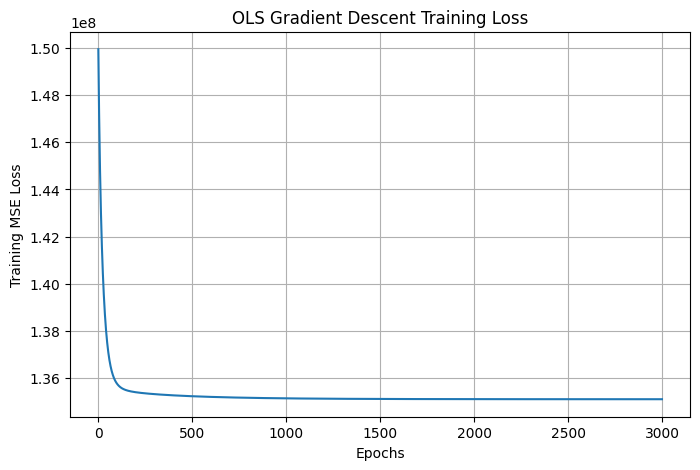

In [9]:
plt.figure(figsize=(8,5))
plt.plot(ols_model.loss_history)
plt.xlabel("Epochs")
plt.ylabel("Training MSE Loss")
plt.title("OLS Gradient Descent Training Loss")
plt.grid(True)
plt.show()

The target variable from the Online News Popularity Dataset is shares, which represents the number of times an article was shared on social media. The columns url and timedelta were removed because they did not provide useful numerical information for regression. The training loss curve shows that the MSE decreases rapidly during the first few iterations and then gradually converges. This indicates that gradient descent successfully minimized the loss function. The model was evaluated using both MSE and MAE on both the training and test datasets. The training and test losses are relatively close, suggesting that the model is not significantly overfitting the training data. The reason that the squared loss values are so large is because some articles are shared at an extremely high rate which skews the target variable shares.

### 3. Implement L1 and L2 Regularization

In [10]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.001, epochs=3000, reg_type=None, lam=0.0):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.reg_type = reg_type
        self.lam = lam
        self.w = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features, dtype=np.float64)
        self.loss_history = []

        for _ in range(self.epochs):
            y_pred = X @ self.w
            error = y_pred - y
            grad = (2 / n_samples) * (X.T @ error)
            reg_grad = np.zeros_like(self.w)

            if self.reg_type == 'l2':
                reg_grad[1:] = 2 * self.lam * self.w[1:]

            elif self.reg_type == 'l1':
                reg_grad[1:] = self.lam * np.sign(self.w[1:])

            grad += reg_grad
            self.w -= self.learning_rate * grad
            mse = np.mean(error ** 2)

            if self.reg_type == 'l2':
                penalty = self.lam * np.sum(self.w[1:] ** 2)
            elif self.reg_type == 'l1':
                penalty = self.lam * np.sum(np.abs(self.w[1:]))
            else:
                penalty = 0.0

            self.loss_history.append(mse + penalty)

        return self

    def predict(self, X):
        return X @ self.w

In [ ]:
def cross_validate_lambda(X_train, y_train, lambdas, reg_type, k=5, learning_rate=0.001, epochs=3000):
    kf = KFold(n_splits=k, shuffle=True, random_state=12)
    avg_cv_losses = []

    for lam in lambdas:
        fold_losses = []

        for train_idx, val_idx in kf.split(X_train):
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]

            mean = X_tr.mean(axis=0)
            std = X_tr.std(axis=0)
            std[std == 0] = 1.0

            X_tr_scaled = (X_tr - mean) / std
            X_val_scaled = (X_val - mean) / std

            X_tr_b = add_bias(X_tr_scaled)
            X_val_b = add_bias(X_val_scaled)

            model = LinearRegressionGD(
                learning_rate=learning_rate,
                epochs=epochs,
                reg_type=reg_type,
                lam=lam
            )

            model.fit(X_tr_b, y_tr)
            y_val_pred = model.predict(X_val_b)

            val_loss = squared_loss(y_val, y_val_pred)
            fold_losses.append(val_loss)

        avg_cv_losses.append(np.mean(fold_losses))

    best_index = np.argmin(avg_cv_losses)
    best_lambda = lambdas[best_index]

    return best_lambda, avg_cv_losses

lambdas = [0.001, 0.01, 0.1, 1.0]

X_train = np.asarray(X_train, dtype=np.float64)
X_test = np.asarray(X_test, dtype=np.float64)
y_train = np.asarray(y_train, dtype=np.float64)
y_test = np.asarray(y_test, dtype=np.float64)

best_lambda_l1, cv_losses_l1 = cross_validate_lambda(
    X_train, y_train, lambdas=lambdas, reg_type='l1', k=5,
    learning_rate=0.001, epochs=500
)

best_lambda_l2, cv_losses_l2 = cross_validate_lambda(
    X_train, y_train, lambdas=lambdas, reg_type='l2', k=5,
    learning_rate=0.001, epochs=500
)

print("Best lambda for L1:", best_lambda_l1)
print("Best lambda for L2:", best_lambda_l2)

Best lambda for L1: 1.0
Best lambda for L2: 1.0


In [ ]:
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)
train_std[train_std == 0] = 1.0

X_train_scaled = (X_train - train_mean) / train_std
X_test_scaled = (X_test - train_mean) / train_std

X_train_b = add_bias(X_train_scaled)
X_test_b = add_bias(X_test_scaled)

ols_model = LinearRegressionGD(
    learning_rate=0.001,
    epochs=3000,
    reg_type=None,
    lam=0.0
)
ols_model.fit(X_train_b, y_train)

l1_model = LinearRegressionGD(
    learning_rate=0.001,
    epochs=3000,
    reg_type='l1',
    lam=best_lambda_l1
)
l1_model.fit(X_train_b, y_train)

l2_model = LinearRegressionGD(
    learning_rate=0.001,
    epochs=3000,
    reg_type='l2',
    lam=best_lambda_l2
)
l2_model.fit(X_train_b, y_train)

models = {
    "OLS": ols_model,
    "L1": l1_model,
    "L2": l2_model
}

for name, model in models.items():
    y_train_pred = model.predict(X_train_b)
    y_test_pred = model.predict(X_test_b)

    print(f"\n{name}")
    print(f"Train Squared Loss:  {squared_loss(y_train, y_train_pred):.4f}")
    print(f"Test Squared Loss:   {squared_loss(y_test, y_test_pred):.4f}")
    print(f"Train Absolute Loss: {absolute_loss(y_train, y_train_pred):.4f}")
    print(f"Test Absolute Loss:  {absolute_loss(y_test, y_test_pred):.4f}")


OLS
Train Squared Loss:  135329169.2447
Test Squared Loss:   128016031.6867
Train Absolute Loss: 3090.7854
Test Absolute Loss:  3024.4119

L1
Train Squared Loss:  135329877.2258
Test Squared Loss:   128013976.8112
Train Absolute Loss: 3090.5392
Test Absolute Loss:  3024.1413

L2
Train Squared Loss:  135929921.1640
Test Squared Loss:   128255488.5063
Train Absolute Loss: 3105.5503
Test Absolute Loss:  3036.7464


In [15]:
feature_names = subset_5k.drop(columns=[" shares"]).columns

ols_weights = ols_model.w[1:]
l1_weights = l1_model.w[1:]
l2_weights = l2_model.w[1:]

comparison_df = pd.DataFrame({
    "Feature": feature_names,
    "OLS Weight": ols_weights,
    "L1 Weight": l1_weights,
    "L2 Weight": l2_weights
})

comparison_df["|OLS|"] = np.abs(comparison_df["OLS Weight"])
comparison_df["|L1|"] = np.abs(comparison_df["L1 Weight"])
comparison_df["|L2|"] = np.abs(comparison_df["L2 Weight"])

comparison_df.head()

,Feature,OLS Weight,L1 Weight,L2 Weight,|OLS|,|L1|,|L2|
0,n_tokens_title,175.026064,174.358615,62.723171,175.026064,174.358615,62.723171
1,n_tokens_content,277.926083,276.331162,74.795668,277.926083,276.331162,74.795668
2,n_unique_tokens,14.447974,14.287691,5.289244,14.447974,14.287691,5.289244
3,n_non_stop_words,6.058170,5.903628,3.878961,6.058170,5.903628,3.878961
4,n_non_stop_unique_tokens,5.598888,5.394392,2.510688,5.598888,5.394392,2.510688


In [16]:
threshold = 1e-3

l1_near_zero = np.sum(np.abs(l1_weights) < threshold)
l2_near_zero = np.sum(np.abs(l2_weights) < threshold)

print("Number of near-zero weights in L1:", l1_near_zero)
print("Number of near-zero weights in L2:", l2_near_zero)

Number of near-zero weights in L1: 0
Number of near-zero weights in L2: 0


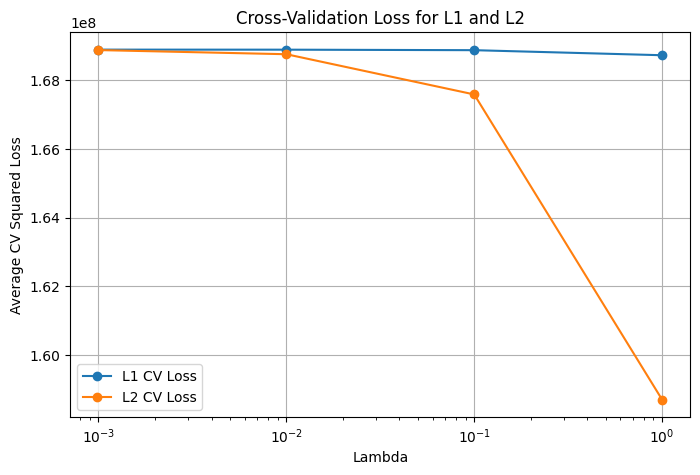

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(lambdas, cv_losses_l1, marker='o', label='L1 CV Loss')
plt.plot(lambdas, cv_losses_l2, marker='o', label='L2 CV Loss')
plt.xscale('log')
plt.xlabel("Lambda")
plt.ylabel("Average CV Squared Loss")
plt.title("Cross-Validation Loss for L1 and L2")
plt.legend()
plt.grid(True)
plt.show()

Using 5-fold cross-validation, the optimal regularization parameter lambda was found to be 1.0 for both the L1 and L2 regularization models. The models were evaluated using squared loss and absolute loss. L1 regularization produced the lowest test loss, although the improvement over OLS was small. L2 regularization slightly increased both squared and absolute losses compared to OLS. This suggests that the original OLS model was not heavily overfitting, so regularization had only a small effect.

### 4. Dataset Scaling and Observations

In [19]:
train_sizes = [0.2, 0.4, 0.6, 0.8]
test_errors = []

for train_size in train_sizes:

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=train_size, random_state=12
    )

    X_train = np.asarray(X_train, dtype=np.float64)
    X_test = np.asarray(X_test, dtype=np.float64)
    y_train = np.asarray(y_train, dtype=np.float64)
    y_test = np.asarray(y_test, dtype=np.float64)

    best_lambda, _ = cross_validate_lambda(
        X_train,
        y_train,
        lambdas,
        reg_type='l2',
        k=5,
        learning_rate=0.001,
        epochs=500
    )

    train_mean = X_train.mean(axis=0)
    train_std = X_train.std(axis=0)
    train_std[train_std == 0] = 1.0

    X_train_scaled = (X_train - train_mean) / train_std
    X_test_scaled = (X_test - train_mean) / train_std

    X_train_b = add_bias(X_train_scaled)
    X_test_b = add_bias(X_test_scaled)

    model = LinearRegressionGD(
        learning_rate=0.001,
        epochs=3000,
        reg_type='l2',
        lam=best_lambda
    )

    model.fit(X_train_b, y_train)
    y_test_pred = model.predict(X_test_b)
    test_mse = squared_loss(y_test, y_test_pred)
    test_errors.append(test_mse)

    print(f"Training size {int(train_size*100)}% | Test MSE: {test_mse:.2f}")

Training size 20% | Test MSE: 153809804.77
Training size 40% | Test MSE: 144230997.87
Training size 60% | Test MSE: 128255488.51
Training size 80% | Test MSE: 199735294.97


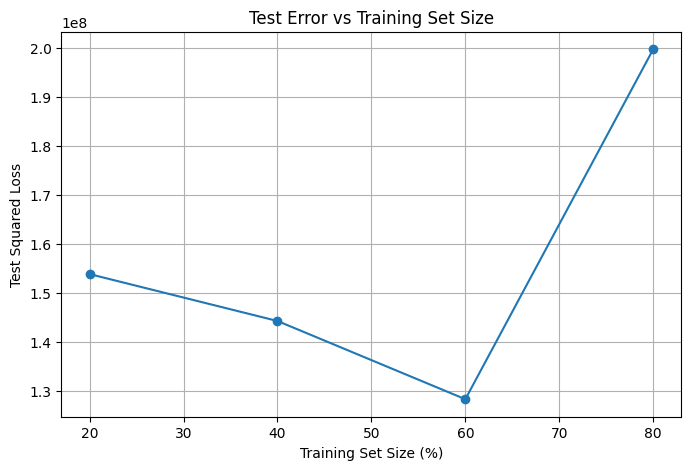

In [20]:
plt.figure(figsize=(8,5))

plt.plot(
    [int(s*100) for s in train_sizes],
    test_errors,
    marker='o'
)

plt.xlabel("Training Set Size (%)")
plt.ylabel("Test Squared Loss")
plt.title("Test Error vs Training Set Size")
plt.grid(True)

plt.show()

In [21]:
datasets = {
    "5K": subset_5k,
    "10K": subset_10k,
    "20K": subset_20k
}

dataset_errors = {}

for name, dataset in datasets.items():

    X_full = dataset.drop(columns=[" shares"]).to_numpy(dtype=np.float64)
    y_full = dataset[" shares"].to_numpy(dtype=np.float64)

    errors = []

    for train_size in train_sizes:

        X_train, X_test, y_train, y_test = train_test_split(
            X_full, y_full, train_size=train_size, random_state=12
        )

        best_lambda, _ = cross_validate_lambda(
            X_train,
            y_train,
            lambdas,
            reg_type='l2',
            k=5,
            learning_rate=0.001,
            epochs=500
        )

        train_mean = X_train.mean(axis=0)
        train_std = X_train.std(axis=0)
        train_std[train_std == 0] = 1.0

        X_train_scaled = (X_train - train_mean) / train_std
        X_test_scaled = (X_test - train_mean) / train_std

        X_train_b = add_bias(X_train_scaled)
        X_test_b = add_bias(X_test_scaled)

        model = LinearRegressionGD(
            learning_rate=0.001,
            epochs=3000,
            reg_type='l2',
            lam=best_lambda
        )

        model.fit(X_train_b, y_train)

        y_test_pred = model.predict(X_test_b)

        errors.append(squared_loss(y_test, y_test_pred))

    dataset_errors[name] = errors

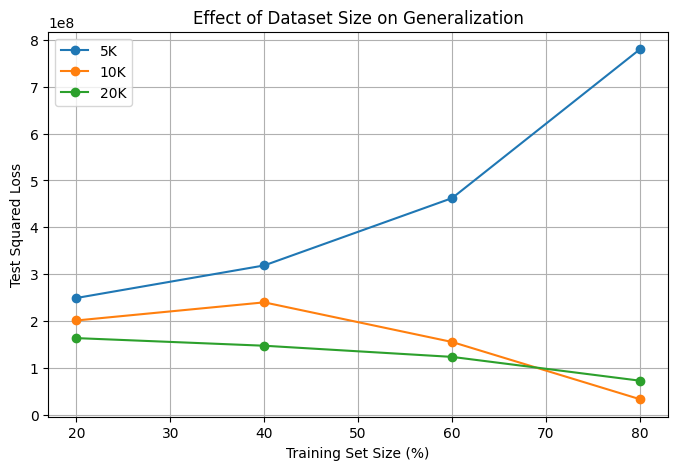

In [22]:
plt.figure(figsize=(8,5))

for name, errors in dataset_errors.items():
    plt.plot(
        [int(s*100) for s in train_sizes],
        errors,
        marker='o',
        label=name
    )

plt.xlabel("Training Set Size (%)")
plt.ylabel("Test Squared Loss")
plt.title("Effect of Dataset Size on Generalization")
plt.legend()
plt.grid(True)

plt.show()

A) The results show that the test error initially decreases as the training size increases from 20% to 60%. This is expected because larger training datasets provide more information for the model to learn the relationship between the features and the target variable. However, when the training size increases to 80%, the test error increases significantly. This occurs because the test set becomes very small, making the test error estimate unstable and more sensitive to outliers. Since we know that the dataset contains highly skewed values for the shares variable due to some articles going viral receiving significantly more shares than others, a smaller test set may contain more extreme values leading to an increase in the measured error.

B) The results show that larger datasets generally lead to lower and more stable test errors. When the dataset size increases from 5K to 10K and 20K samples, the model has access to more examples of the underlying data distribution. This allows the regression model to learn more accurate relationships between features and the target variable shares. As the dataset size increases, the model becomes less sensitive to noise, parameter estimates become more stable, and generalization performance improves. The plot shows that 20K dataset produces the most stable performance, which makes sense as increasing dataset size generally improves model performance.

### 5. Additional Questions

When k is small, each validation set is relatively large and the training set is smaller. This makes the model evaluation run faster but results in a higher amount of bias being present. When k is large, the model is trained on almost the entire dataset. This reduces bias, but increases variance and causes the computation to take much longer. In this instance, a value of k = 5 was chosen for 5-fold cross-validation to determine the best regularization parameter lambda.

In this dataset, null values were checked for using df.isna().sum(). Since no null values were found, that meant that there weren't any missing values present in the dataset so no additional data cleaning was required.